In [364]:
from IPython.display import Image
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re

# Models
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    BaggingClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    GradientBoostingRegressor,
    ExtraTreesClassifier,
    RandomForestRegressor,
    AdaBoostRegressor,
    VotingClassifier
)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
# Model selection
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV , RandomizedSearchCV

# Metrics
from sklearn.metrics import (
    mean_squared_error,
    accuracy_score,
    roc_auc_score,
    roc_curve,
    recall_score,
    confusion_matrix,
    precision_score,
    f1_score,
    classification_report,
    r2_score
)

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder , OneHotEncoder , PowerTransformer
from sklearn.impute import SimpleImputer

In [347]:
import platform
print(platform.architecture())

('64bit', '')


In [240]:
sns.color_palette("Paired")

[(0.6509803921568628, 0.807843137254902, 0.8901960784313725),
 (0.12156862745098039, 0.47058823529411764, 0.7058823529411765),
 (0.6980392156862745, 0.8745098039215686, 0.5411764705882353),
 (0.2, 0.6274509803921569, 0.17254901960784313),
 (0.984313725490196, 0.6039215686274509, 0.6),
 (0.8901960784313725, 0.10196078431372549, 0.10980392156862745),
 (0.9921568627450981, 0.7490196078431373, 0.43529411764705883),
 (1.0, 0.4980392156862745, 0.0),
 (0.792156862745098, 0.6980392156862745, 0.8392156862745098),
 (0.41568627450980394, 0.23921568627450981, 0.6039215686274509),
 (1.0, 1.0, 0.6),
 (0.6941176470588235, 0.34901960784313724, 0.1568627450980392)]

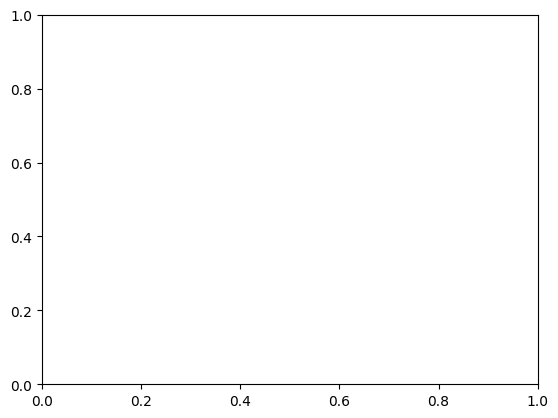

In [241]:
plt.ticklabel_format(style='plain', axis='both')

In [242]:
weather = pd.read_csv('weatherAUS.csv')
weather['Date'] = pd.to_datetime(weather['Date'])
weather['month'] = weather['Date'].dt.month
weather['month_name'] = weather['Date'].dt.month_name()
weather['Year'] = weather['Date'].dt.year
weather = weather[(weather['Year'] >= 2008) & (weather['Year'] <= 2016)]

In [243]:
weather.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,month,month_name,Year
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,1007.1,8.0,NaN,16.9,21.8,No,No,12,December,2008
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,1007.8,NaN,NaN,17.2,24.3,No,No,12,December,2008
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,1008.7,NaN,2.0,21.0,23.2,No,No,12,December,2008
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,1012.8,NaN,NaN,18.1,26.5,No,No,12,December,2008
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,1006.0,7.0,8.0,17.8,29.7,No,No,12,December,2008


In [244]:
weather.info()

<class 'pandas.DataFrame'>
Index: 136776 entries, 0 to 145283
Data columns (total 26 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Date           136776 non-null  datetime64[us]
 1   Location       136776 non-null  str           
 2   MinTemp        135397 non-null  float64       
 3   MaxTemp        135596 non-null  float64       
 4   Rainfall       133667 non-null  float64       
 5   Evaporation    79739 non-null   float64       
 6   Sunshine       73333 non-null   float64       
 7   WindGustDir    126990 non-null  str           
 8   WindGustSpeed  127053 non-null  float64       
 9   WindDir9am     126819 non-null  str           
 10  WindDir3pm     132954 non-null  str           
 11  WindSpeed9am   135058 non-null  float64       
 12  WindSpeed3pm   134075 non-null  float64       
 13  Humidity9am    134251 non-null  float64       
 14  Humidity3pm    132863 non-null  float64       
 15  Pressure9am    1

In [245]:
weather.describe()

,Date,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,month,Year
count,136776,135397.000000,135596.000000,133667.000000,79739.000000,73333.000000,127053.000000,135058.000000,134075.000000,134251.000000,132863.000000,122600.000000,122635.000000,84921.000000,82133.000000,135062.000000,133701.000000,136776.000000,136776.000000
mean,2013-01-04 01:06:41.754693,12.098337,23.106464,2.353053,5.442234,7.608791,40.192573,14.117653,18.751721,68.731600,51.523863,1017.614560,1015.219132,4.416964,4.496585,16.912206,21.579214,6.584101,2012.505630
min,2008-01-01 00:00:00,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.500000,977.100000,0.000000,0.000000,-7.200000,-5.400000,1.000000,2008.000000
25%,2010-11-26 00:00:00,7.500000,17.800000,0.000000,2.600000,4.800000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.900000,1010.400000,1.000000,2.000000,12.200000,16.500000,4.000000,2010.000000
50%,2013-03-07 00:00:00,11.900000,22.500000,0.000000,4.600000,8.400000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.600000,1015.200000,5.000000,5.000000,16.600000,21.000000,7.000000,2013.000000
75%,2015-02-03 00:00:00,16.700000,28.100000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.400000,1020.000000,7.000000,7.000000,21.500000,26.300000,10.000000,2015.000000
max,2016-12-31 00:00:00,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,87.000000,87.000000,100.000000,100.000000,1041.000000,1039.600000,9.000000,9.000000,40.200000,46.100000,12.000000,2016.000000
std,NaN,6.376063,7.108744,8.456922,4.168819,3.785345,13.650052,8.947005,8.837086,19.041159,20.793608,7.102844,7.030513,2.884193,2.714257,6.480545,6.928115,3.422677,2.374007


In [246]:
weather['RainTomorrow'] = np.where(weather['RainTomorrow'] == 'Yes',1,0)
weather['RainToday'] = np.where(weather['RainTomorrow'] == 'Yes',1,0)

<Axes: >

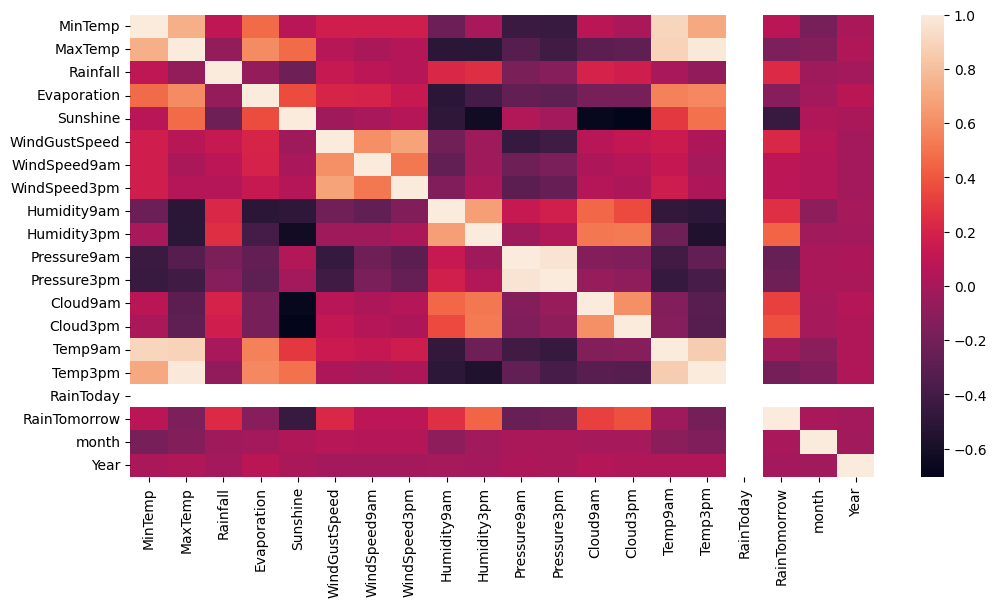

In [247]:
plt.figure(figsize=(12,6))
sns.heatmap(weather.corr(numeric_only=True))

In [248]:
weather.dtypes

Date             datetime64[us]
Location                    str
MinTemp                 float64
MaxTemp                 float64
Rainfall                float64
Evaporation             float64
Sunshine                float64
WindGustDir                 str
WindGustSpeed           float64
WindDir9am                  str
WindDir3pm                  str
WindSpeed9am            float64
WindSpeed3pm            float64
Humidity9am             float64
Humidity3pm             float64
Pressure9am             float64
Pressure3pm             float64
Cloud9am                float64
Cloud3pm                float64
Temp9am                 float64
Temp3pm                 float64
RainToday                 int64
RainTomorrow              int64
month                     int32
month_name                  str
Year                      int32
dtype: object

In [249]:
weather['WindDir3pm']

0         WNW
1         WSW
2         WSW
3           E
4          NW
         ... 
145279      W
145280      W
145281    WSW
145282      W
145283    ENE
Name: WindDir3pm, Length: 136776, dtype: str

In [250]:
weather['RainTomorrow'].value_counts()

RainTomorrow
0    106681
1     30095
Name: count, dtype: int64

In [251]:
weather['Location'].unique()

<ArrowStringArray>
[          'Albury',    'BadgerysCreek',            'Cobar',
     'CoffsHarbour',            'Moree',        'Newcastle',
        'NorahHead',    'NorfolkIsland',          'Penrith',
         'Richmond',           'Sydney',    'SydneyAirport',
       'WaggaWagga',      'Williamtown',       'Wollongong',
         'Canberra',      'Tuggeranong',      'MountGinini',
         'Ballarat',          'Bendigo',             'Sale',
 'MelbourneAirport',        'Melbourne',          'Mildura',
             'Nhil',         'Portland',         'Watsonia',
         'Dartmoor',         'Brisbane',           'Cairns',
        'GoldCoast',       'Townsville',         'Adelaide',
     'MountGambier',        'Nuriootpa',          'Woomera',
           'Albany',      'Witchcliffe',       'PearceRAAF',
     'PerthAirport',            'Perth',       'SalmonGums',
          'Walpole',           'Hobart',       'Launceston',
     'AliceSprings',           'Darwin',        'Katherine',
     

In [252]:
weather['Rainfall'].describe()

count    133667.000000
mean          2.353053
std           8.456922
min           0.000000
25%           0.000000
50%           0.000000
75%           0.800000
max         371.000000
Name: Rainfall, dtype: float64

# Avg yearly rainfall in Australia after 2014

In [253]:
newDf = weather.groupby(["Year",'month_name','month'])["Rainfall"].mean().reset_index().sort_values(by='month')
newDf = newDf[newDf['Year'] >= 2014]

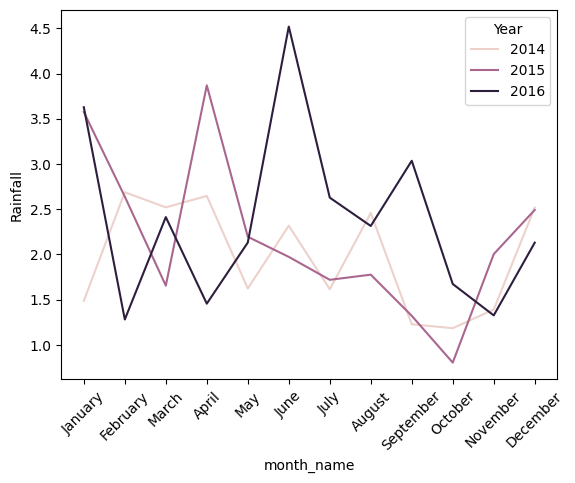

In [254]:
sns.lineplot(
    data=newDf,
    x='month_name',
    y='Rainfall',
    hue='Year'
)

plt.xticks(rotation=45)
plt.show()

# Maximum rainfall in each month since 2014

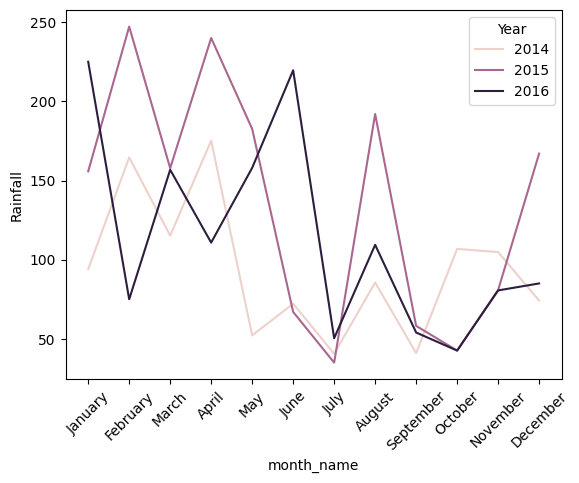

In [255]:
newDf = weather.groupby(["Year",'month_name','month'])["Rainfall"].max().reset_index().sort_values(by='month')
newDf = newDf[newDf['Year'] >= 2014]
sns.lineplot(
    data=newDf,
    x='month_name',
    y='Rainfall',
    hue='Year'
)

plt.xticks(rotation=45)
plt.show()

# Citites with the most rainfall in 2017

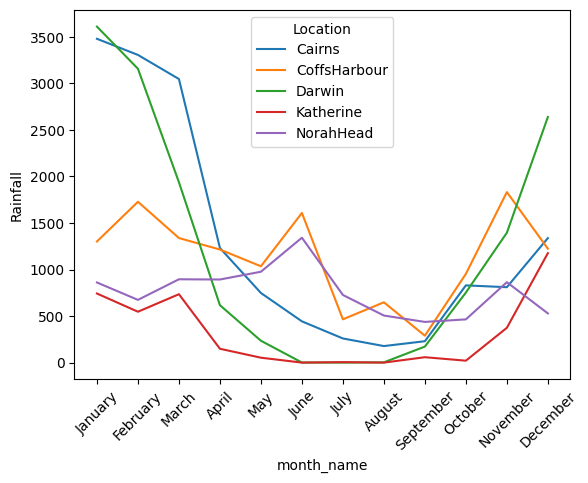

In [256]:
top5_monthly = (
    weather[weather['Year'] == 2014]
    .groupby(['Location'])['Rainfall']
    .sum()
    .reset_index()
    .sort_values('Rainfall',ascending=False)
    .head(5)
)

rain_by_location_month = (
    weather[weather['Location'].isin(top5_monthly['Location'])]
    .groupby(['Location','month','month_name'])['Rainfall']
    .sum()
    .reset_index()
    .sort_values(['Location','month'])
)

sns.lineplot(
    data=rain_by_location_month,
    x='month_name',
    y='Rainfall',
    hue='Location'
)

plt.xticks(rotation=45)
plt.show()

In [257]:
weather.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,month,month_name,Year
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,1007.1,8.0,NaN,16.9,21.8,0,0,12,December,2008
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,1007.8,NaN,NaN,17.2,24.3,0,0,12,December,2008
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,1008.7,NaN,2.0,21.0,23.2,0,0,12,December,2008
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,1012.8,NaN,NaN,18.1,26.5,0,0,12,December,2008
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,1006.0,7.0,8.0,17.8,29.7,0,0,12,December,2008


# Lowest regions for rainfall

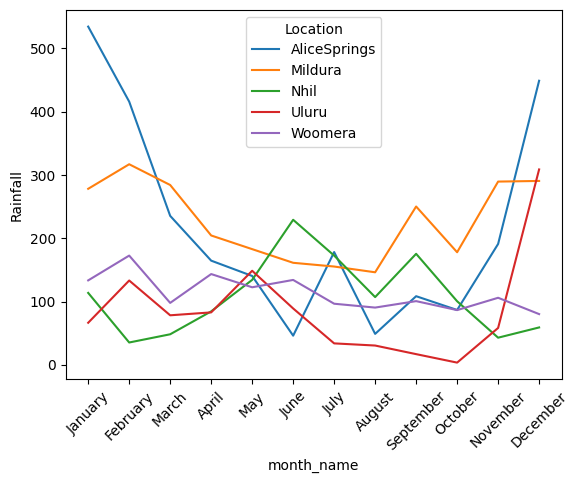

In [258]:
top5_monthly = (
    weather[weather['Year'] == 2014]
    .groupby(['Location'])['Rainfall']
    .sum()
    .reset_index()
    .sort_values('Rainfall',ascending=True)
    .head(5)
)

rain_by_location_month = (
    weather[weather['Location'].isin(top5_monthly['Location'])]
    .groupby(['Location','month','month_name'])['Rainfall']
    .sum()
    .reset_index()
    .sort_values(['Location','month'])
)

sns.lineplot(
    data=rain_by_location_month,
    x='month_name',
    y='Rainfall',
    hue='Location'
)

plt.xticks(rotation=45)
plt.show()

# Comparision of rainfall over the years in Melbourne

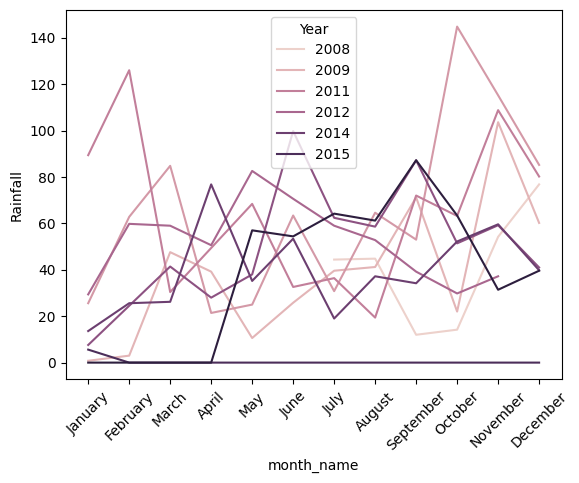

In [259]:
newDf = weather[weather['Location'] == 'Melbourne'].groupby(["month_name","Year",'month'])["Rainfall"].sum().reset_index().sort_values(by='month')
sns.lineplot(
    data=newDf,
    x='month_name',
    y='Rainfall',
    hue='Year'
)
plt.xticks(rotation=45)
plt.show()

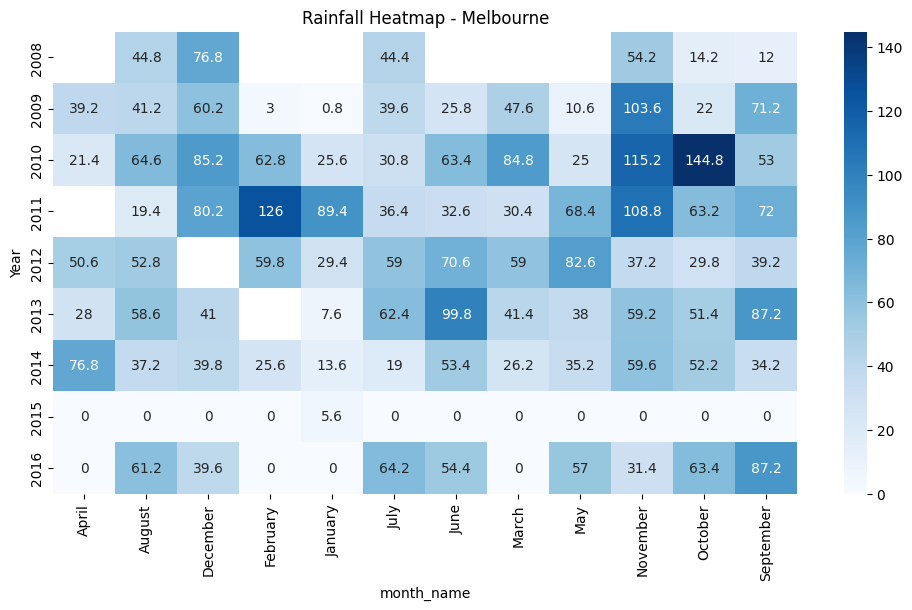

In [260]:
pivot = weather[weather['Location'] == 'Melbourne'].pivot_table(
    values='Rainfall',
    index='Year',
    columns='month_name',
    aggfunc='sum'
)
plt.figure(figsize=(12,6))
sns.heatmap(pivot, cmap="Blues", annot=True,fmt='g')
plt.title("Rainfall Heatmap - Melbourne")
plt.show()

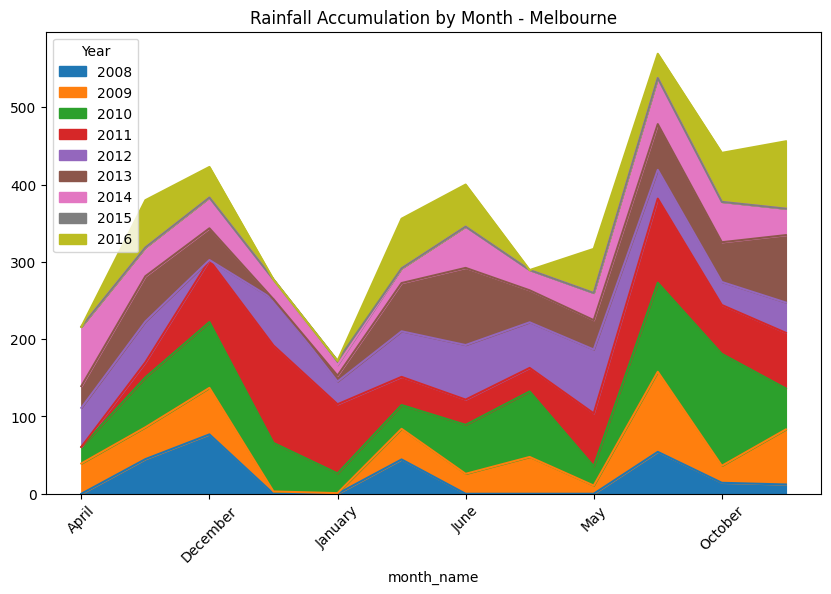

In [261]:
pivot = newDf.pivot(index='month_name', columns='Year', values='Rainfall')

pivot.plot(kind='area', figsize=(10,6))
plt.xticks(rotation=45)
plt.title("Rainfall Accumulation by Month - Melbourne")
plt.show()

In [262]:
season_map = {
    "December": "Summer",
    "January": "Summer",
    "February": "Summer",

    "March": "Autumn",
    "April": "Autumn",
    "May": "Autumn",

    "June": "Winter",
    "July": "Winter",
    "August": "Winter",

    "September": "Spring",
    "October": "Spring",
    "November": "Spring"
}

In [263]:
weather['Season'] = weather['month_name'].map(season_map)

In [264]:
weather[(weather['Season'] == 'Spring')]

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,month,month_name,Year,Season
274,2009-09-01,Albury,5.1,14.2,3.0,NaN,NaN,WNW,24.0,WNW,...,8.0,1.0,9.7,12.5,0,0,9,September,2009,Spring
275,2009-09-02,Albury,1.0,16.8,0.0,NaN,NaN,ESE,24.0,ESE,...,NaN,NaN,7.0,16.0,0,0,9,September,2009,Spring
276,2009-09-03,Albury,6.1,20.7,0.0,NaN,NaN,NE,43.0,SE,...,NaN,NaN,10.2,20.3,0,1,9,September,2009,Spring
277,2009-09-04,Albury,6.3,16.9,1.4,NaN,NaN,NW,35.0,ESE,...,1.0,NaN,12.5,15.5,0,0,9,September,2009,Spring
278,2009-09-05,Albury,2.1,15.0,0.0,NaN,NaN,WNW,30.0,ESE,...,NaN,6.0,8.6,14.9,0,0,9,September,2009,Spring
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145248,2016-11-26,Uluru,16.1,34.2,0.0,NaN,NaN,E,50.0,E,...,NaN,NaN,26.4,32.2,0,0,11,November,2016,Spring
145249,2016-11-27,Uluru,16.8,35.5,0.0,NaN,NaN,ENE,37.0,ENE,...,NaN,NaN,27.3,34.0,0,0,11,November,2016,Spring
145250,2016-11-28,Uluru,14.9,38.7,0.0,NaN,NaN,SSW,37.0,NE,...,NaN,NaN,30.5,37.0,0,0,11,November,2016,Spring
145251,2016-11-29,Uluru,17.1,41.5,0.0,NaN,NaN,SSE,63.0,NE,...,NaN,4.0,30.9,39.2,0,0,11,November,2016,Spring


<Axes: xlabel='Year', ylabel='Rainfall'>

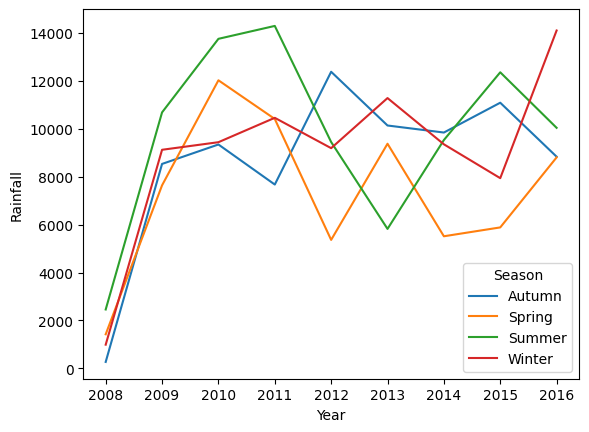

In [265]:
newDf = weather.groupby(["Season",'Year'])["Rainfall"].sum().reset_index()
sns.lineplot(
    x='Year',
    y='Rainfall',
    data=newDf,
    hue='Season'
)

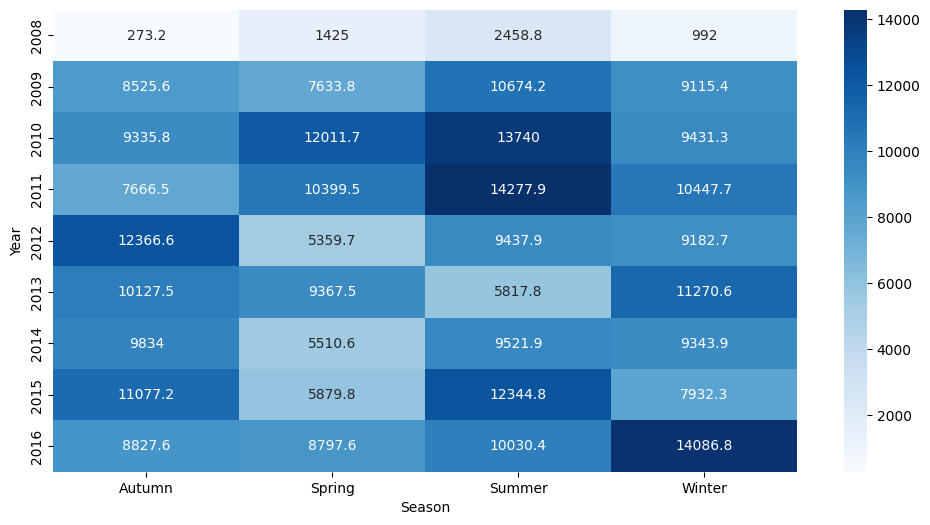

In [266]:
pivot = weather.pivot_table(
    values='Rainfall',
    index='Year',
    columns='Season',
    aggfunc='sum'
)
plt.figure(figsize=(12,6))
sns.heatmap(pivot, cmap="Blues", annot=True,fmt='g')
# plt.title("Rainfall Heatmap - Melbourne")
plt.show()

In [267]:
weather[(weather['Year'] == 2007) & (weather['Season'] == 'Autumn')]['Rainfall'].sum()

np.float64(0.0)

# Yearly Rainfall trend

In [268]:
weather[weather['Year'] == 2008]['Rainfall'].sum()

np.float64(5149.0)

<Axes: xlabel='Year', ylabel='Rainfall'>

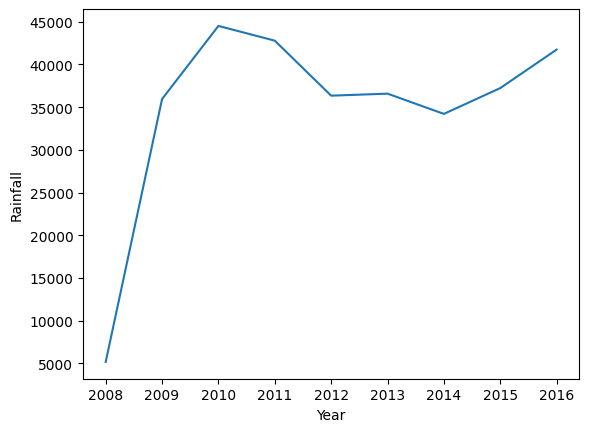

In [269]:
newDf = weather[(weather['Year'] > 2007) & (weather['Year'] < 2017)].groupby("Year")["Rainfall"].sum().reset_index()
sns.lineplot(
    data=newDf,
    x='Year',
    y='Rainfall'

)

# Rainfall by Year

In [270]:
driest = weather.groupby('Location')['Rainfall'].sum().reset_index().sort_values(by='Rainfall').min()
wettest = weather.groupby('Location')['Rainfall'].sum().reset_index().sort_values(by='Rainfall').max()
print(driest)
print(wettest)
location = [driest.Location,wettest.Location]

Location    Adelaide
Rainfall      1049.6
dtype: object
Location    Woomera
Rainfall    15901.0
dtype: object


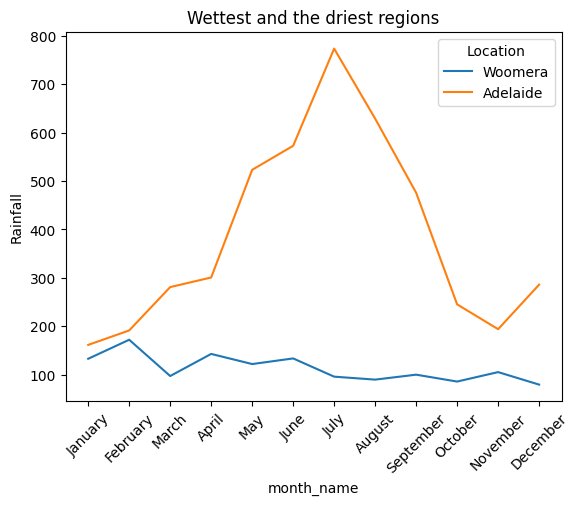

In [271]:
newDf = weather[weather['Location'].isin(location)].groupby(["month_name",'Location','month'])['Rainfall'].sum().reset_index().sort_values(by='month')

sns.lineplot(
    data=newDf,
    x='month_name',
    y='Rainfall',
    hue='Location'
)
plt.xticks(rotation=45)
plt.title("Wettest and the driest regions")
plt.show()

In [272]:
newDf = weather.groupby("Year")["RainToday"].count()
newDf

Year
2008     2270
2009    16789
2010    16782
2011    15407
2012    15409
2013    16415
2014    17885
2015    17885
2016    17934
Name: RainToday, dtype: int64

In [273]:
rainy_days = weather[weather['Rainfall'] > 0]
newDf = rainy_days[rainy_days['Location'].isin(location)].groupby(['Year','Location'])['Rainfall'].count().reset_index()
newDf

,Year,Location,Rainfall
0,2008,Adelaide,63
1,2009,Adelaide,117
2,2009,Woomera,48
3,2010,Adelaide,129
4,2010,Woomera,61
5,2011,Adelaide,113
6,2011,Woomera,48
7,2012,Adelaide,115
8,2012,Woomera,32
9,2013,Adelaide,114


# Number of rainy days in the wettest and driest regions

Text(0.5, 1.0, 'Number of rainy days in the driest and the wettest regions')

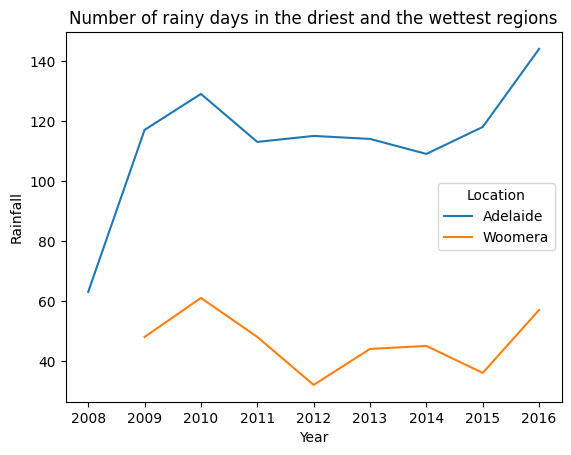

In [274]:
sns.lineplot(
    x='Year',
    y='Rainfall',
    data=newDf,
    hue='Location'
)
plt.title("Number of rainy days in the driest and the wettest regions")

<Axes: >

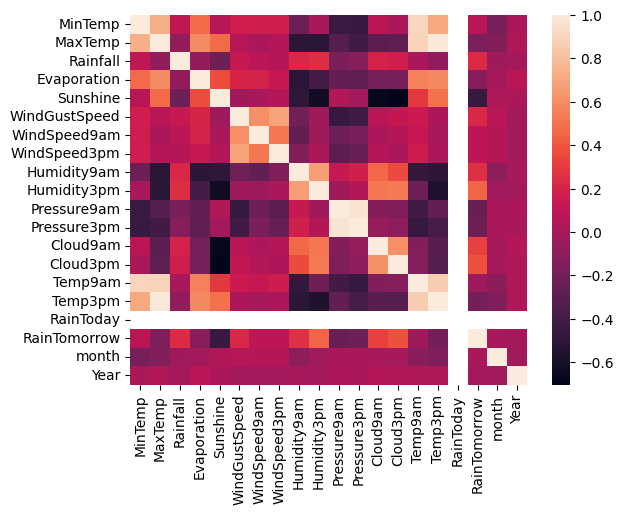

In [275]:
sns.heatmap(weather.corr(numeric_only=True))

In [276]:
weather.columns

Index(['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation',
       'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'RainToday', 'RainTomorrow', 'month', 'month_name', 'Year',
       'Season'],
      dtype='str')

<Axes: >

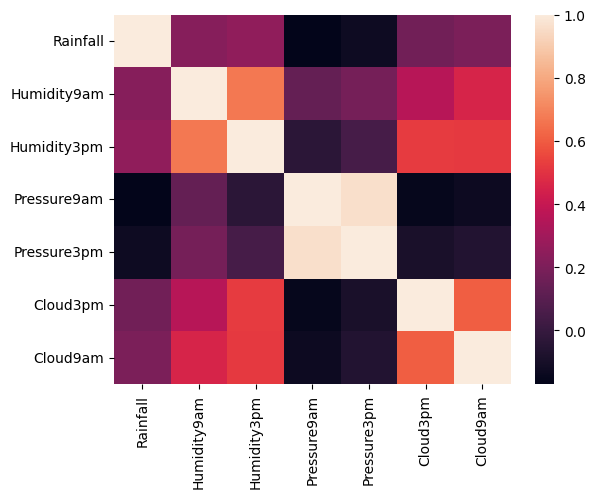

In [277]:
sns.heatmap(weather[['Rainfall','Humidity9am','Humidity3pm','Pressure9am','Pressure3pm','Cloud3pm','Cloud9am']].corr())

In [278]:
weather['Location'].unique()

<ArrowStringArray>
[          'Albury',    'BadgerysCreek',            'Cobar',
     'CoffsHarbour',            'Moree',        'Newcastle',
        'NorahHead',    'NorfolkIsland',          'Penrith',
         'Richmond',           'Sydney',    'SydneyAirport',
       'WaggaWagga',      'Williamtown',       'Wollongong',
         'Canberra',      'Tuggeranong',      'MountGinini',
         'Ballarat',          'Bendigo',             'Sale',
 'MelbourneAirport',        'Melbourne',          'Mildura',
             'Nhil',         'Portland',         'Watsonia',
         'Dartmoor',         'Brisbane',           'Cairns',
        'GoldCoast',       'Townsville',         'Adelaide',
     'MountGambier',        'Nuriootpa',          'Woomera',
           'Albany',      'Witchcliffe',       'PearceRAAF',
     'PerthAirport',            'Perth',       'SalmonGums',
          'Walpole',           'Hobart',       'Launceston',
     'AliceSprings',           'Darwin',        'Katherine',
     

In [279]:
coastal_cities = {
    'Albury': 0,
    'BadgerysCreek': 0,
    'Cobar': 0,
    'CoffsHarbour': 1,
    'Moree': 0,
    'Newcastle': 1,
    'NorahHead': 1,
    'NorfolkIsland': 1,
    'Penrith': 0,
    'Richmond': 0,
    'Sydney': 1,
    'SydneyAirport': 1,
    'WaggaWagga': 0,
    'Williamtown': 1,
    'Wollongong': 1,
    'Canberra': 0,
    'Tuggeranong': 0,
    'MountGinini': 0,
    'Ballarat': 0,
    'Bendigo': 0,
    'Sale': 0,
    'MelbourneAirport': 1,
    'Melbourne': 1,
    'Mildura': 0,
    'Nhil': 0,
    'Portland': 1,
    'Watsonia': 0,
    'Dartmoor': 0,
    'Brisbane': 1,
    'Cairns': 1,
    'GoldCoast': 1,
    'Townsville': 1,
    'Adelaide': 1,
    'MountGambier': 0,
    'Nuriootpa': 0,
    'Woomera': 0,
    'Albany': 1,
    'Witchcliffe': 0,
    'PearceRAAF': 0,
    'PerthAirport': 1,
    'Perth': 1,
    'SalmonGums': 0,
    'Walpole': 1,
    'Hobart': 1,
    'Launceston': 0,
    'AliceSprings': 0,
    'Darwin': 1,
    'Katherine': 0,
    'Uluru': 0
}
weather['Coastal'] = weather['Location'].map(coastal_cities)

print(weather['Coastal'].value_counts())

Coastal
0    72833
1    63943
Name: count, dtype: int64


<Axes: >

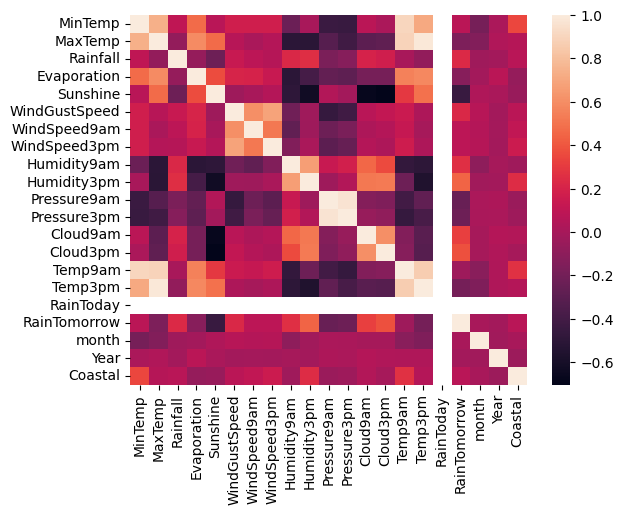

In [280]:
sns.heatmap(weather.corr(numeric_only=True))

In [281]:
newDf = weather.groupby(['Coastal','Year'])[['MinTemp','MaxTemp']].mean().reset_index().sort_values(['Coastal','Year'])
newDf

,Coastal,Year,MinTemp,MaxTemp
0,0,2008,9.223758,22.145497
1,0,2009,10.020044,22.830891
2,0,2010,9.757535,21.797540
3,0,2011,9.842522,21.895303
4,0,2012,8.801582,21.607377
5,0,2013,9.908696,23.061981
6,0,2014,10.564371,23.780601
7,0,2015,10.332558,23.250284
8,0,2016,10.760102,23.127684
9,1,2008,13.737895,23.164462


Text(0.5, 1.0, 'Avergage Min Temps of coastal cities')

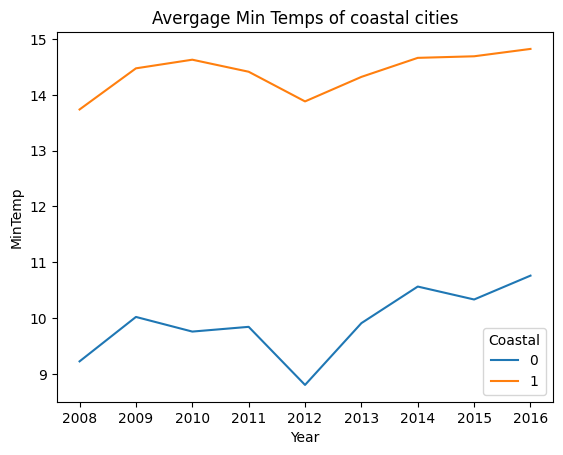

In [282]:
sns.lineplot(
    data=newDf,
    x='Year',
    y='MinTemp',
    hue='Coastal'
)

plt.title("Avergage Min Temps of coastal cities")

Text(0.5, 1.0, 'Avergage Max Temps of coastal cities')

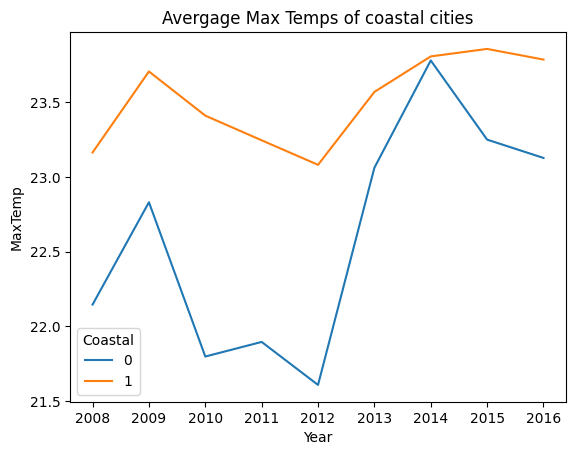

In [283]:
sns.lineplot(
    data=newDf,
    x='Year',
    y='MaxTemp',
    hue='Coastal'
)

plt.title("Avergage Max Temps of coastal cities")

In [284]:
weather.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,month,month_name,Year,Season,Coastal
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,NaN,16.9,21.8,0,0,12,December,2008,Summer,0
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,NaN,17.2,24.3,0,0,12,December,2008,Summer,0
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,2.0,21.0,23.2,0,0,12,December,2008,Summer,0
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,NaN,18.1,26.5,0,0,12,December,2008,Summer,0
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,8.0,17.8,29.7,0,0,12,December,2008,Summer,0


In [285]:
weather.isna().sum()

Date                 0
Location             0
MinTemp           1379
MaxTemp           1180
Rainfall          3109
Evaporation      57037
Sunshine         63443
WindGustDir       9786
WindGustSpeed     9723
WindDir9am        9957
WindDir3pm        3822
WindSpeed9am      1718
WindSpeed3pm      2701
Humidity9am       2525
Humidity3pm       3913
Pressure9am      14176
Pressure3pm      14141
Cloud9am         51855
Cloud3pm         54643
Temp9am           1714
Temp3pm           3075
RainToday            0
RainTomorrow         0
month                0
month_name           0
Year                 0
Season               0
Coastal              0
dtype: int64

In [286]:
categorical = [var for var in weather.columns if weather[var].dtype=='O']
numerical = [var for var in weather.columns if weather[var].dtype!='O']

In [287]:
cols = ['Evaporation','Rainfall']

for col in cols:
    weather[col] = weather[col].fillna(0)

weather.isna().sum()

Date                 0
Location             0
MinTemp           1379
MaxTemp           1180
Rainfall             0
Evaporation          0
Sunshine         63443
WindGustDir       9786
WindGustSpeed     9723
WindDir9am        9957
WindDir3pm        3822
WindSpeed9am      1718
WindSpeed3pm      2701
Humidity9am       2525
Humidity3pm       3913
Pressure9am      14176
Pressure3pm      14141
Cloud9am         51855
Cloud3pm         54643
Temp9am           1714
Temp3pm           3075
RainToday            0
RainTomorrow         0
month                0
month_name           0
Year                 0
Season               0
Coastal              0
dtype: int64

Text(0, 0.5, 'WindSpeed3pm')

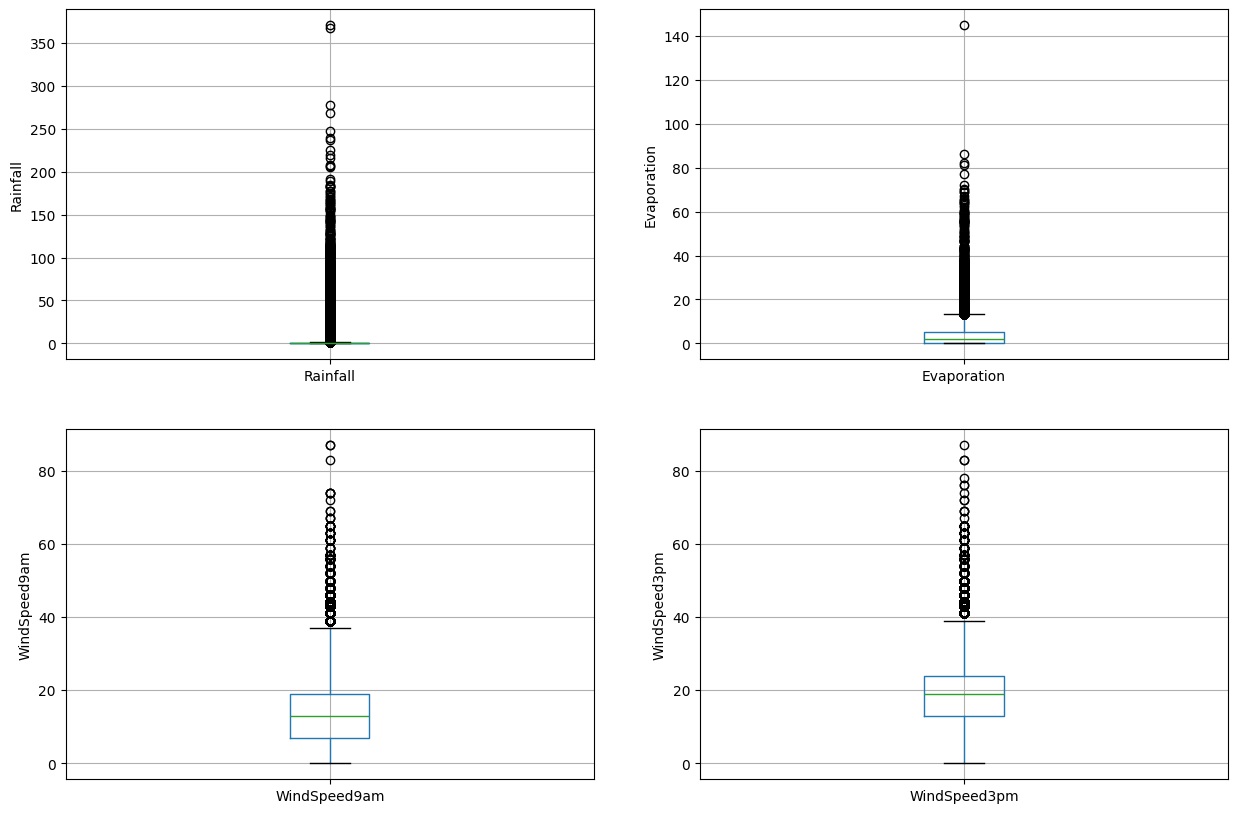

In [288]:
# draw boxplots to visualize outliers

plt.figure(figsize=(15,10))


plt.subplot(2, 2, 1)
fig = weather.boxplot(column='Rainfall')
fig.set_title('')
fig.set_ylabel('Rainfall')


plt.subplot(2, 2, 2)
fig = weather.boxplot(column='Evaporation')
fig.set_title('')
fig.set_ylabel('Evaporation')


plt.subplot(2, 2, 3)
fig = weather.boxplot(column='WindSpeed9am')
fig.set_title('')
fig.set_ylabel('WindSpeed9am')


plt.subplot(2, 2, 4)
fig = weather.boxplot(column='WindSpeed3pm')
fig.set_title('')
fig.set_ylabel('WindSpeed3pm')

Text(0, 0.5, 'RainTomorrow')

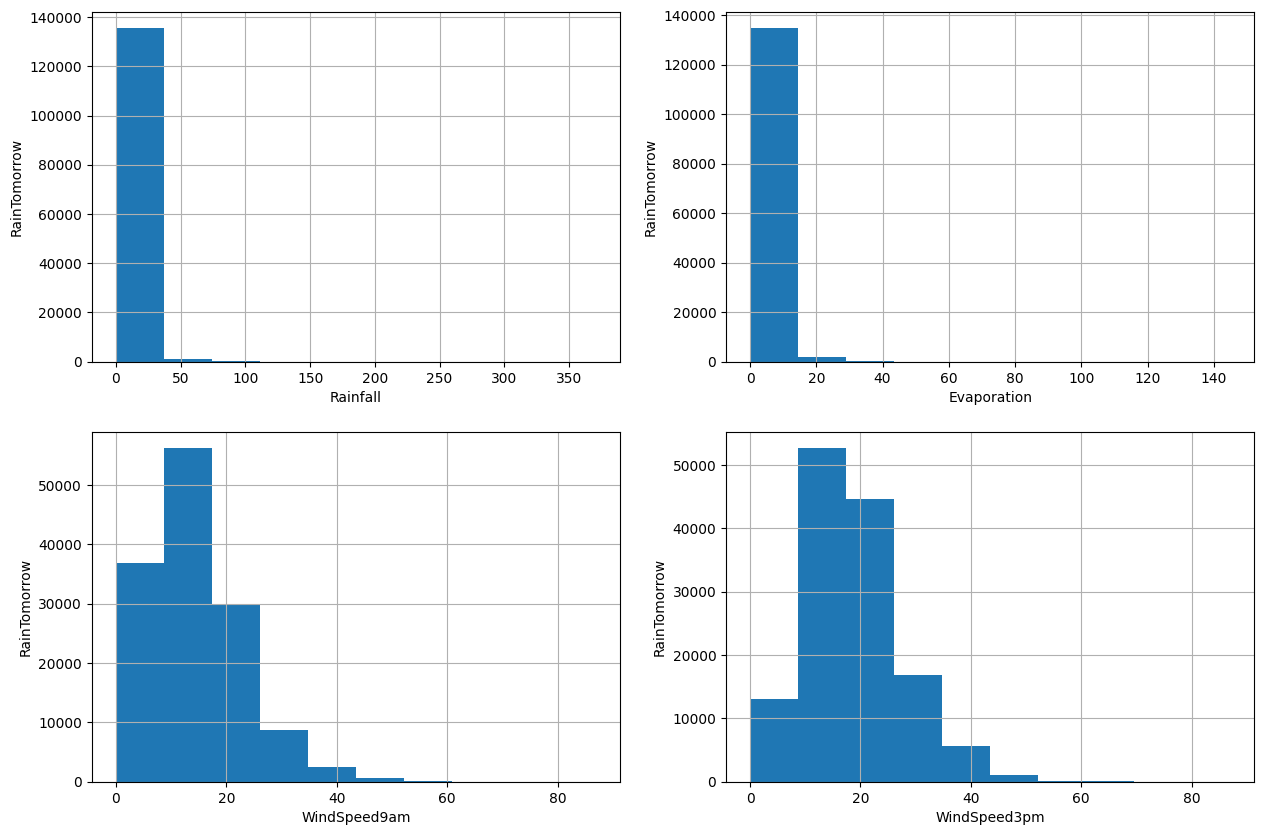

In [289]:
plt.figure(figsize=(15,10))


plt.subplot(2, 2, 1)
fig = weather.Rainfall.hist(bins=10)
fig.set_xlabel('Rainfall')
fig.set_ylabel('RainTomorrow')


plt.subplot(2, 2, 2)
fig = weather.Evaporation.hist(bins=10)
fig.set_xlabel('Evaporation')
fig.set_ylabel('RainTomorrow')


plt.subplot(2, 2, 3)
fig = weather.WindSpeed9am.hist(bins=10)
fig.set_xlabel('WindSpeed9am')
fig.set_ylabel('RainTomorrow')


plt.subplot(2, 2, 4)
fig = weather.WindSpeed3pm.hist(bins=10)
fig.set_xlabel('WindSpeed3pm')
fig.set_ylabel('RainTomorrow')


In [290]:
IQR = weather.Rainfall.quantile(0.75) - weather.Rainfall.quantile(0.25)
Lower_fence = weather.Rainfall.quantile(0.25) - (IQR * 3)
Upper_fence = weather.Rainfall.quantile(0.75) + (IQR * 3)
print('Rainfall outliers are values < {lowerboundary} or > {upperboundary}'.format(lowerboundary=Lower_fence, upperboundary=Upper_fence))

Rainfall outliers are values < -1.7999999999999998 or > 2.4


In [291]:
cols = ['Rainfall','Evaporation','WindSpeed9am','WindSpeed3pm']

weather_no_outliers = weather.copy()

for col in cols:
    Q1 = weather[col].quantile(0.25)
    Q3 = weather[col].quantile(0.75)
    IQR = Q3 - Q1
    Lower_fence = Q1 - (IQR * 3)
    Upper_fence = Q3 + (IQR * 3)
    
    print(f'{col} outliers are values < {Lower_fence} or > {Upper_fence}')
    
    # Filter the outliers
    weather_no_outliers = weather_no_outliers[(weather_no_outliers[col] >= Lower_fence) & 
                                              (weather_no_outliers[col] <= Upper_fence)]

Rainfall outliers are values < -1.7999999999999998 or > 2.4
Evaporation outliers are values < -16.200000000000003 or > 21.6
WindSpeed9am outliers are values < -29.0 or > 55.0
WindSpeed3pm outliers are values < -20.0 or > 57.0


In [305]:
weather_no_outliers.isna().sum()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,month,month_name,Year,Season,Coastal
0,2008-12-01,Albury,13.4,22.9,0.6,0.0,9.0,W,44.0,W,...,4.0,16.9,21.8,0,0,12,December,2008,Summer,0
1,2008-12-02,Albury,7.4,25.1,0.0,0.0,9.0,WNW,44.0,NNW,...,4.0,17.2,24.3,0,0,12,December,2008,Summer,0
2,2008-12-03,Albury,12.9,25.7,0.0,0.0,9.0,WSW,46.0,W,...,2.0,21.0,23.2,0,0,12,December,2008,Summer,0
3,2008-12-04,Albury,9.2,28.0,0.0,0.0,9.0,NE,24.0,SE,...,4.0,18.1,26.5,0,0,12,December,2008,Summer,0
4,2008-12-05,Albury,17.5,32.3,1.0,0.0,9.0,W,41.0,ENE,...,8.0,17.8,29.7,0,0,12,December,2008,Summer,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145275,2016-12-23,Uluru,24.8,32.6,0.0,0.0,9.0,NNW,44.0,NNE,...,8.0,28.2,30.0,0,1,12,December,2016,Summer,0
145280,2016-12-28,Uluru,22.6,36.8,0.0,0.0,9.0,NW,50.0,NW,...,4.0,29.7,34.0,0,0,12,December,2016,Summer,0
145281,2016-12-29,Uluru,23.2,38.0,0.0,0.0,9.0,SSW,33.0,S,...,4.0,28.7,36.4,0,0,12,December,2016,Summer,0
145282,2016-12-30,Uluru,19.7,37.0,0.0,0.0,9.0,E,37.0,ESE,...,4.0,28.2,35.1,0,0,12,December,2016,Summer,0


In [306]:
# Fill missing values only for numeric columns to avoid median on string/object dtypes
numeric_cols = weather_no_outliers.select_dtypes(include=[np.number]).columns.tolist()

for col in numeric_cols:
    col_median = weather_no_outliers[col].median()
    weather_no_outliers[col] = weather_no_outliers[col].fillna(col_median)

date_cols = weather_no_outliers.select_dtypes(include=['datetime64[ns]']).columns.tolist()

for col in date_cols:
    col_median = weather_no_outliers[col].median()
    weather_no_outliers[col] = weather_no_outliers[col].fillna(col_median)

['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm', 'RainToday', 'RainTomorrow', 'month', 'Year', 'Coastal']


In [294]:
weather_no_outliers['WindGustDir'] = weather_no_outliers['WindGustDir'].fillna(weather_no_outliers['WindGustDir'].mode()[0])
weather_no_outliers['WindDir9am'] = weather_no_outliers['WindDir9am'].fillna(weather_no_outliers['WindDir9am'].mode()[0])
weather_no_outliers['WindDir3pm'] = weather_no_outliers['WindDir3pm'].fillna(weather_no_outliers['WindDir3pm'].mode()[0])
weather_no_outliers['RainToday'] = weather_no_outliers['RainToday'].fillna(weather_no_outliers['RainToday'].mode()[0])

In [311]:
categorical = [var for var in weather_no_outliers.columns if weather_no_outliers[var].dtype == 'str']

weather_encoded = pd.get_dummies(weather_no_outliers, columns=categorical, drop_first=True)

print(weather_encoded)

             Date  MinTemp  MaxTemp  Rainfall  Evaporation  Sunshine  \
0      2008-12-01     13.4     22.9       0.6          0.0       9.0   
1      2008-12-02      7.4     25.1       0.0          0.0       9.0   
2      2008-12-03     12.9     25.7       0.0          0.0       9.0   
3      2008-12-04      9.2     28.0       0.0          0.0       9.0   
4      2008-12-05     17.5     32.3       1.0          0.0       9.0   
...           ...      ...      ...       ...          ...       ...   
145275 2016-12-23     24.8     32.6       0.0          0.0       9.0   
145280 2016-12-28     22.6     36.8       0.0          0.0       9.0   
145281 2016-12-29     23.2     38.0       0.0          0.0       9.0   
145282 2016-12-30     19.7     37.0       0.0          0.0       9.0   
145283 2016-12-31     23.7     33.0       0.0          0.0       9.0   

        WindGustSpeed  WindSpeed9am  WindSpeed3pm  Humidity9am  ...  \
0                44.0          20.0          24.0         71.0  

In [326]:
X = weather_encoded.drop(['RainTomorrow','Date'], axis=1)
y = weather_encoded['RainTomorrow']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

X_train.shape, X_test.shape

((88929, 127), (22233, 127))

In [327]:
weather_encoded.isna().sum()

Date                    0
MinTemp                 0
MaxTemp                 0
Rainfall                0
Evaporation             0
                       ..
month_name_October      0
month_name_September    0
Season_Spring           0
Season_Summer           0
Season_Winter           0
Length: 129, dtype: int64

In [328]:
import category_encoders as ce

encoder = ce.BinaryEncoder(cols=['RainToday'])

X_train = encoder.fit_transform(X_train)

X_test = encoder.transform(X_test)

In [329]:
scaler = StandardScaler()

In [350]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Logistic Regression

In [360]:
logreg = LogisticRegression(solver='liblinear', random_state=0)
logreg.fit(X_train, y_train)
y_pred_test = logreg.predict(X_test)
print('Model accuracy score: {0:0.4f}'. format(accuracy_score(y_test, y_pred_test)))

Model accuracy score: 0.8674


              precision    recall  f1-score   support

           0       0.88      0.97      0.92     18494
           1       0.70      0.37      0.49      3739

    accuracy                           0.87     22233
   macro avg       0.79      0.67      0.71     22233
weighted avg       0.85      0.87      0.85     22233



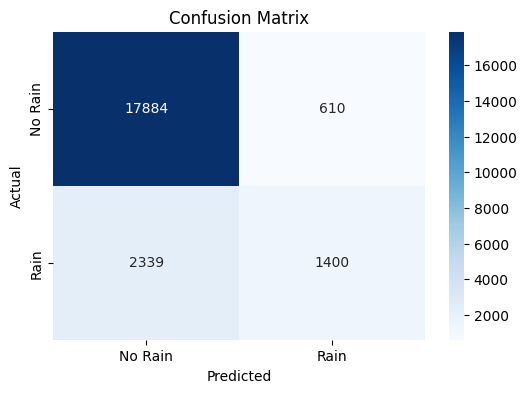

In [361]:
print(classification_report(y_test, y_pred_test))
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Rain','Rain'],
    yticklabels=['No Rain','Rain']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

# Descision Tree Regressor

In [362]:
rf = RandomForestRegressor(n_estimators=400,min_samples_leaf=0.12,random_state=1)

# Fit 'rf' to training set
rf.fit(X_train,y_train)

# Predict the test set labels 'y_pred'
y_pred = rf.predict(X_test)

# Evaluate the test set RMSE
print('Model accuracy score: {0:0.4f}'. format(accuracy_score(y_test, y_pred)))



ValueError: Classification metrics can't handle a mix of binary and continuous targets

In [ ]:
param_dist = {
    "max_depth": [3, 5, 7, 10, 15, None],
    "min_samples_split": [2, 5, 10, 20, 50],
    "min_samples_leaf": [1, 2, 5, 10, 20],
    "max_features": [None, "sqrt", "log2"]
}

model = DecisionTreeClassifier(random_state=42)

random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=50,                 # number of random combinations to test
    scoring="neg_mean_squared_error",
    cv=5,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

best_tree = random_search.best_estimator_
y_pred = random_search.predict(X_test)

print("Best Parameters:", random_search.best_params_)
print("Best Score:", random_search.best_score_)
print('Model accuracy score: {0:0.4f}'. format(accuracy_score(y_test, y_pred)))

0.01s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.01s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.01s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.01s - Debugger warning: It seems that frozen modules are being used, which may
0

Best Parameters: {'min_samples_split': 50, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 5}
Best Score: -0.13715435258929604
Model accuracy score: 0.8586


In [ ]:
print(classification_report(y_test, y_pred_test))
cm = confusion_matrix(y_test, y_pred_test)
print(cm)

              precision    recall  f1-score   support

           0       0.88      0.97      0.92     18494
           1       0.70      0.37      0.49      3739

    accuracy                           0.87     22233
   macro avg       0.79      0.67      0.71     22233
weighted avg       0.85      0.87      0.85     22233

[[17884   610]
 [ 2339  1400]]


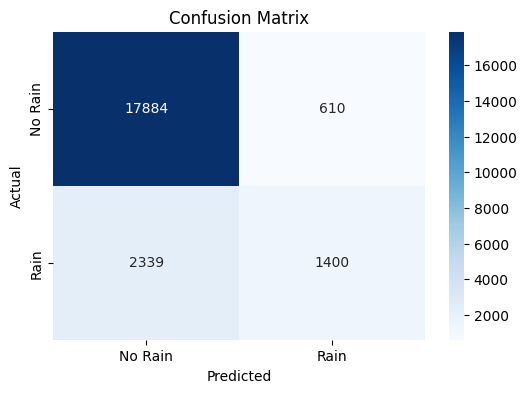

In [ ]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Rain','Rain'],
    yticklabels=['No Rain','Rain']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

Voting Classifier Accuracy: 0.8693833490756983
              precision    recall  f1-score   support

           0       0.88      0.97      0.93     18494
           1       0.73      0.36      0.48      3739

    accuracy                           0.87     22233
   macro avg       0.80      0.67      0.70     22233
weighted avg       0.86      0.87      0.85     22233



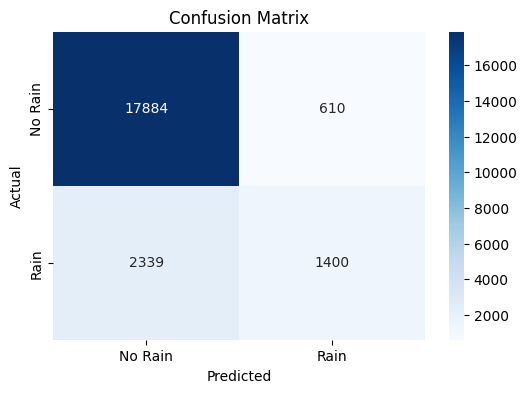

In [365]:
log_model = LogisticRegression(solver='liblinear', random_state=0)

tree_model = DecisionTreeClassifier(
    max_depth=10,
    min_samples_leaf=5,
    random_state=42
)

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

voting_model = VotingClassifier(
    estimators=[
        ('lr', log_model),
        ('dt', tree_model),
        ('rf', rf_model)
    ],
    voting='soft'
)

voting_model.fit(X_train, y_train)
y_pred = voting_model.predict(X_test)
print("Voting Classifier Accuracy:",
      accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Rain','Rain'],
    yticklabels=['No Rain','Rain']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()